In [1]:
import pandas
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sklearn.model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from astroML.classification import GMMBayes
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

## Loading Data

In [3]:
data=pandas.read_csv("galaxyquasar.csv", sep=",")

In [4]:
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [5]:
u_g=data['u']-data['g']
g_r=data['g']-data['r']
r_i=data['r']-data['i']
i_z=data['i']-data['z']
z=data['z1']

In [6]:
y=np.zeros(len(data['class']))
y[data['class']=='QSO']=1

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

X=np.array([u_g,g_r,r_i,i_z])
X=X.transpose()
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
y_train, y_test = train_test_split(y, test_size=0.2, random_state=42)

gnb = GaussianNB()
gnb.fit(X_train,y_train)

y_pred = gnb.predict(X_test)

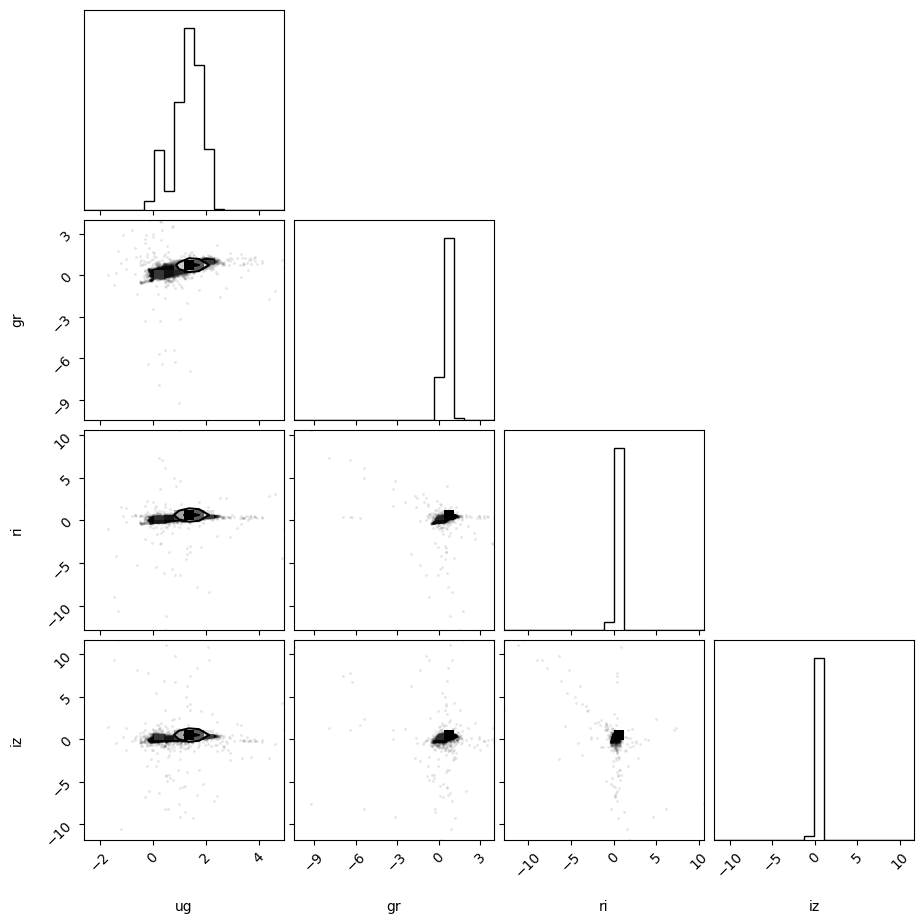

In [8]:
import corner
corner.corner(np.array([u_g,g_r,r_i,i_z]).T, labels=['ug', 'gr', 'ri', 'iz']);

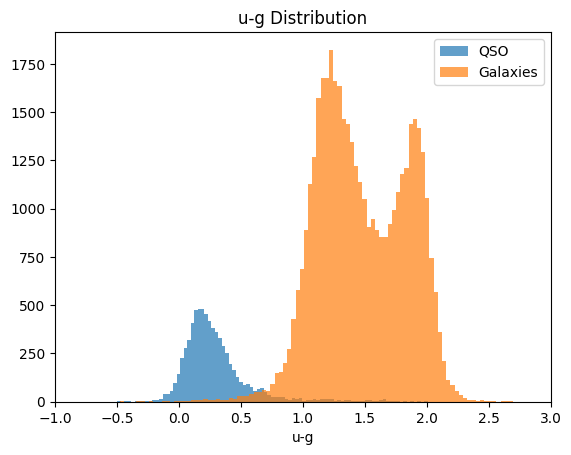

In [9]:
plt.hist(u_g[y==1],bins=200, label='QSO', alpha=0.7);
plt.hist(u_g[y==0],bins=200, label='Galaxies', alpha=0.7);
plt.title("u-g Distribution")
plt.xlabel('u-g')
plt.xlim(-1,3)
plt.legend();

## GaussianNB

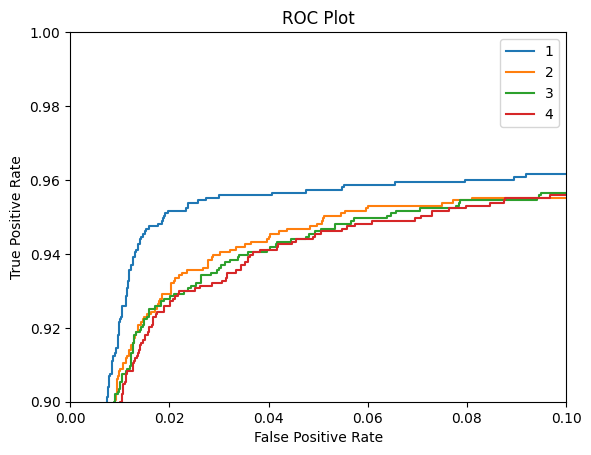

In [10]:
clf = GaussianNB()

for i in range(4):

    clf.fit(X_train[:,0:i+1] ,y_train )

    y_prob = clf.predict_proba(X_test[:,0:i+1]) [:,1] 
    
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(i+1))
plt.legend();

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Plot')

plt.xlim(0,0.1)
plt.ylim(0.9,1);

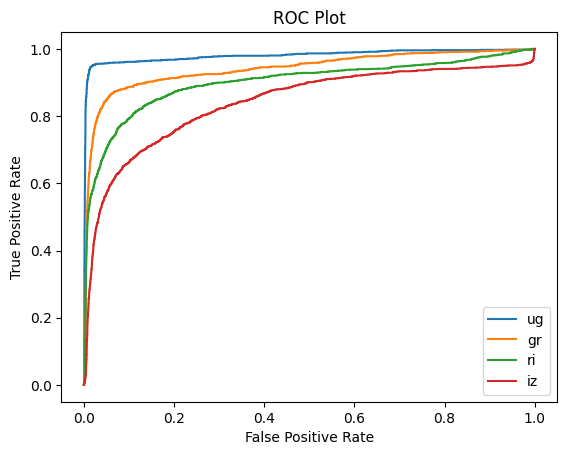

In [11]:
clf = GaussianNB()
labels=['ug', 'gr', 'ri', 'iz']

for i in range(4):

    clf.fit(X_train[:,i:i+1], y_train )

    y_prob = clf.predict_proba(X_test[:,i:i+1]) [:,1] 
    
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=labels[i])
plt.legend();

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Plot');

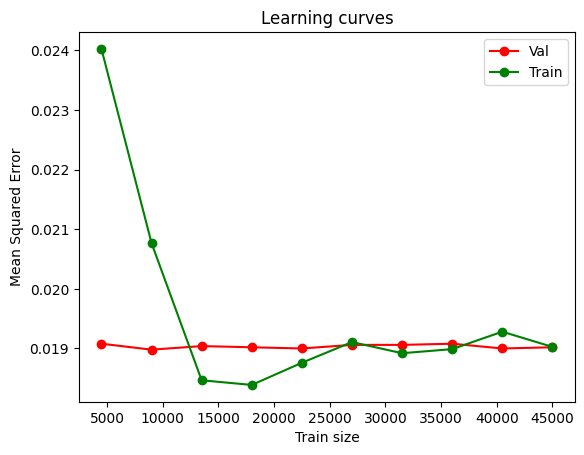

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve

scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

train_sizes, train_scores_clf, test_scores_clf = \
    learning_curve(clf, Xscaled[:,0:1], y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)


plt.plot(train_sizes, -test_scores_clf.mean(1), 'o-', color="r", label="Val")
plt.plot(train_sizes, -train_scores_clf.mean(1), 'o-', color="g", label="Train")
                   
plt.xlabel("Train size")
plt.ylabel("Mean Squared Error")
plt.title('Learning curves')
plt.legend(loc="best");

[[8480   92]
 [ 106 1322]]


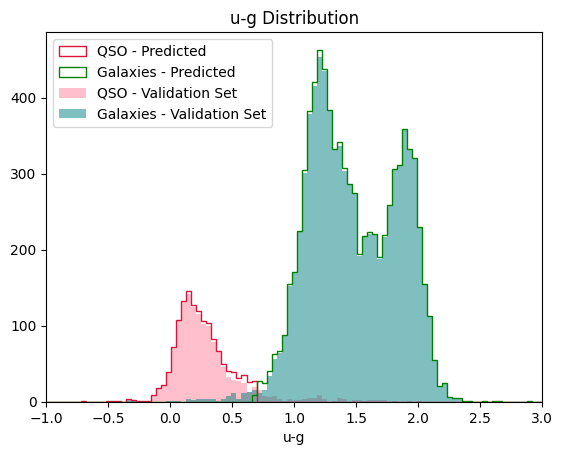

In [13]:
clf = GaussianNB()
clf.fit(X_train[:,0:1] ,y_train )
y_pred = clf.predict(X_test[:,0:1])

plt.hist(X_test[:,0][y_pred==1],color='crimson',histtype='step',bins=np.linspace(-1,3,100),label='QSO - Predicted')
plt.hist(X_test[:,0][y_pred==0],color='green',histtype='step',bins=np.linspace(-1,3,100),label='Galaxies - Predicted')
plt.xlim(-1,3)
plt.legend();

plt.hist(X_test[:,0][y_test==1],color='pink',bins=np.linspace(-1,3,100), label='QSO - Validation Set');
plt.hist(X_test[:,0][y_test==0],color='teal',alpha=0.5,bins=np.linspace(-1,3,100), label='Galaxies - Validation Set');
plt.title("u-g Distribution")
plt.xlabel('u-g')
plt.legend();

print(confusion_matrix(y_test, y_pred))

## Linear Discriminant Analysis

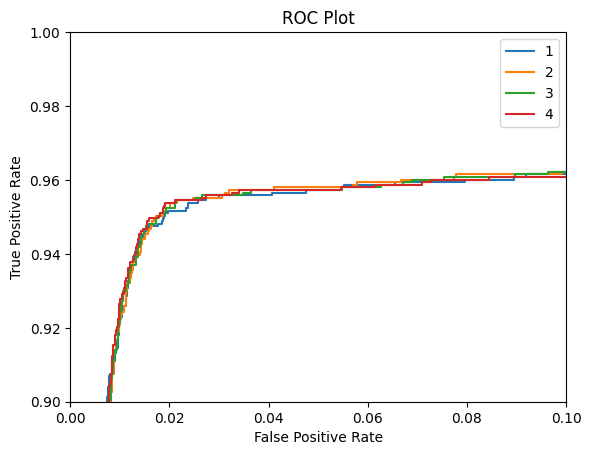

In [14]:
clf = LinearDiscriminantAnalysis()

for i in range(4):

    clf.fit(X_train[:,0:i+1] ,y_train )

    y_prob = clf.predict_proba(X_test[:,0:i+1]) [:,1] 
    
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(i+1))
plt.legend();

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Plot')

plt.xlim(0,0.1)
plt.ylim(0.9,1);

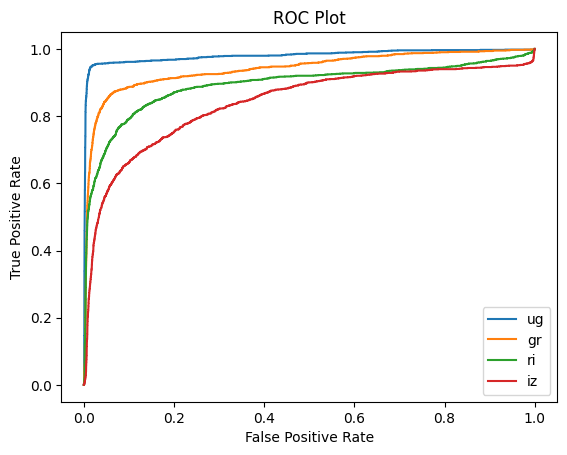

In [15]:
clf = LinearDiscriminantAnalysis()
labels=['ug', 'gr', 'ri', 'iz']

for i in range(4):

    clf.fit(X_train[:,i:i+1], y_train )

    y_prob = clf.predict_proba(X_test[:,i:i+1]) [:,1] 
    
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=labels[i])
plt.legend();

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Plot');

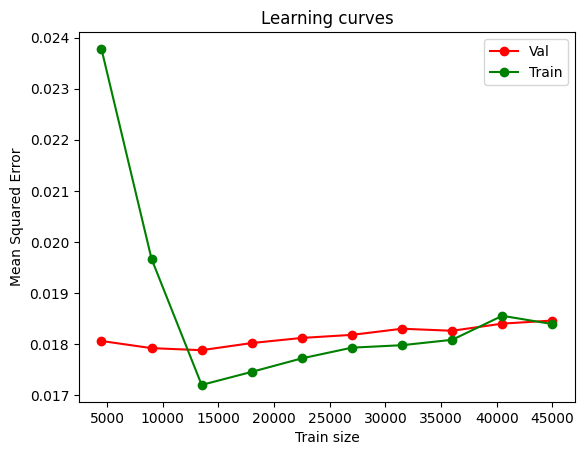

In [16]:
scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

train_sizes, train_scores_clf, test_scores_clf = \
    learning_curve(clf, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)


plt.plot(train_sizes, -test_scores_clf.mean(1), 'o-', color="r", label="Val")
plt.plot(train_sizes, -train_scores_clf.mean(1), 'o-', color="g", label="Train")
                   
plt.xlabel("Train size")
plt.ylabel("Mean Squared Error")
plt.title('Learning curves')
plt.legend(loc="best");

[[8487   85]
 [ 107 1321]]


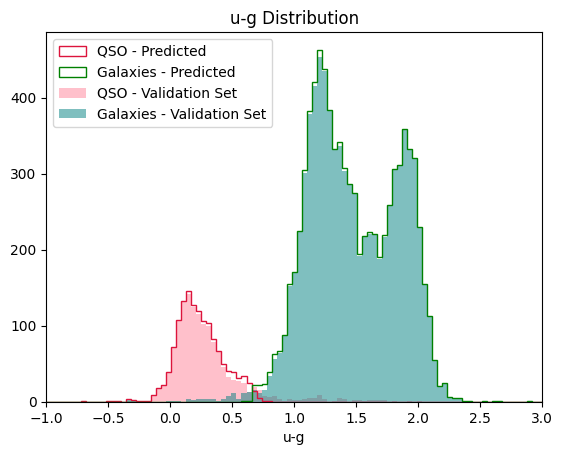

In [17]:
clf = LinearDiscriminantAnalysis()
clf.fit(X_train,y_train )

y_pred = clf.predict(X_test[:,0:4])

plt.hist(X_test[:,0][y_pred==1],color='crimson',histtype='step',bins=np.linspace(-1,3,100),label='QSO - Predicted')
plt.hist(X_test[:,0][y_pred==0],color='green',histtype='step',bins=np.linspace(-1,3,100),label='Galaxies - Predicted')
plt.xlim(-1,3)
plt.legend();

plt.hist(X_test[:,0][y_test==1],color='pink',bins=np.linspace(-1,3,100), label='QSO - Validation Set');
plt.hist(X_test[:,0][y_test==0],color='teal',alpha=0.5,bins=np.linspace(-1,3,100), label='Galaxies - Validation Set');
plt.title("u-g Distribution")
plt.xlabel('u-g')
plt.legend();

print(confusion_matrix(y_test, y_pred))

## Quadratic Discriminant Analysis

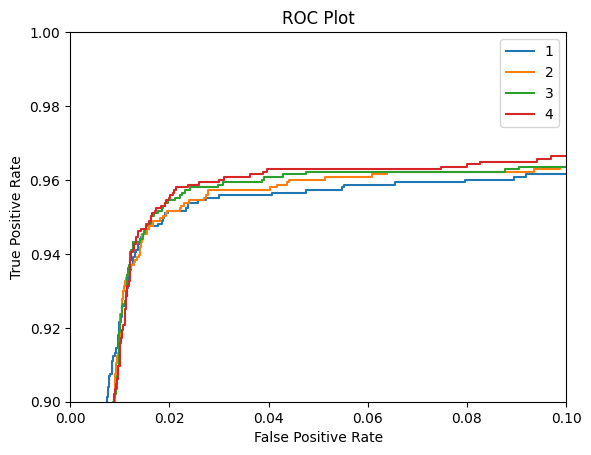

In [18]:
clf = QuadraticDiscriminantAnalysis()

for i in range(4):

    clf.fit(X_train[:,0:i+1] ,y_train )

    y_prob = clf.predict_proba(X_test[:,0:i+1]) [:,1] 
    
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(i+1))
plt.legend();

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Plot')

plt.xlim(0,0.1)
plt.ylim(0.9,1);

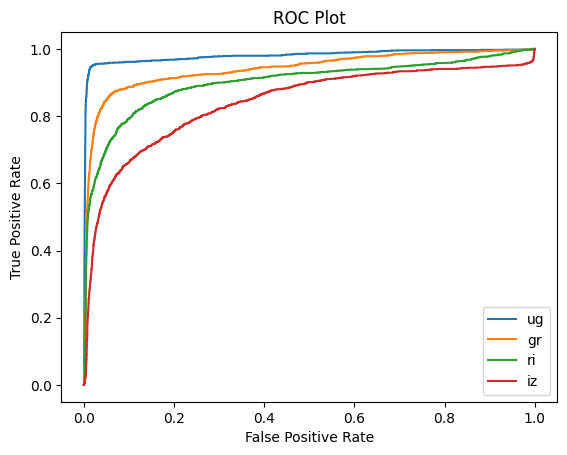

In [19]:
clf = QuadraticDiscriminantAnalysis()
labels=['ug', 'gr', 'ri', 'iz']

for i in range(4):

    clf.fit(X_train[:,i:i+1], y_train )

    y_prob = clf.predict_proba(X_test[:,i:i+1]) [:,1] 
    
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=labels[i])
plt.legend();

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Plot');

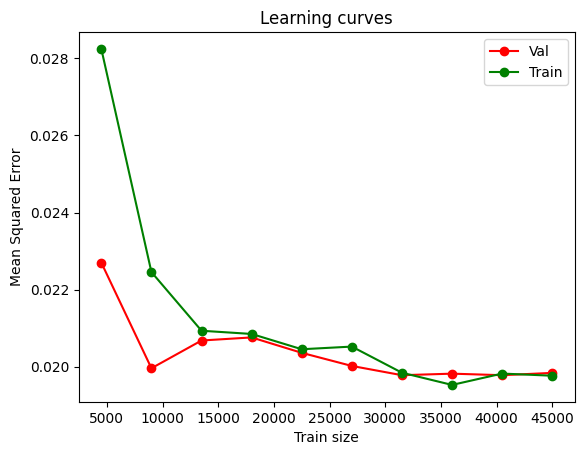

In [20]:
scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

train_sizes, train_scores_clf, test_scores_clf = \
    learning_curve(clf, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)


plt.plot(train_sizes, -test_scores_clf.mean(1), 'o-', color="r", label="Val")
plt.plot(train_sizes, -train_scores_clf.mean(1), 'o-', color="g", label="Train")
                   
plt.xlabel("Train size")
plt.ylabel("Mean Squared Error")
plt.title('Learning curves')
plt.legend(loc="best");

[[8477   95]
 [ 113 1315]]


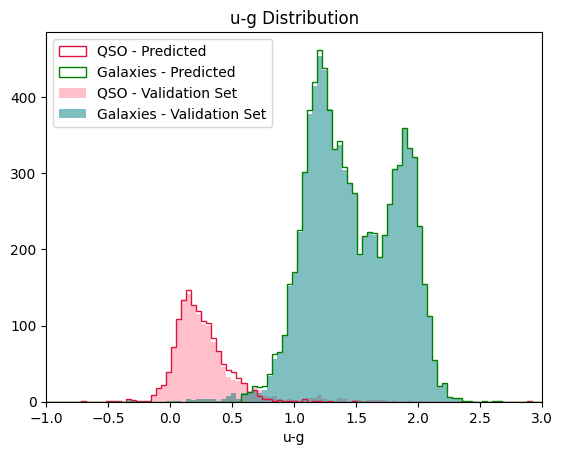

In [21]:
clf = QuadraticDiscriminantAnalysis()
clf.fit(X_train,y_train )

y_pred = clf.predict(X_test[:,0:4])

plt.hist(X_test[:,0][y_pred==1],color='crimson',histtype='step',bins=np.linspace(-1,3,100),label='QSO - Predicted')
plt.hist(X_test[:,0][y_pred==0],color='green',histtype='step',bins=np.linspace(-1,3,100),label='Galaxies - Predicted')
plt.xlim(-1,3)
plt.legend();

plt.hist(X_test[:,0][y_test==1],color='pink',bins=np.linspace(-1,3,100), label='QSO - Validation Set');
plt.hist(X_test[:,0][y_test==0],color='teal',alpha=0.5,bins=np.linspace(-1,3,100), label='Galaxies - Validation Set');
plt.title("u-g Distribution")
plt.xlabel('u-g')
plt.legend();

print(confusion_matrix(y_test, y_pred))

## GMM Bayes 

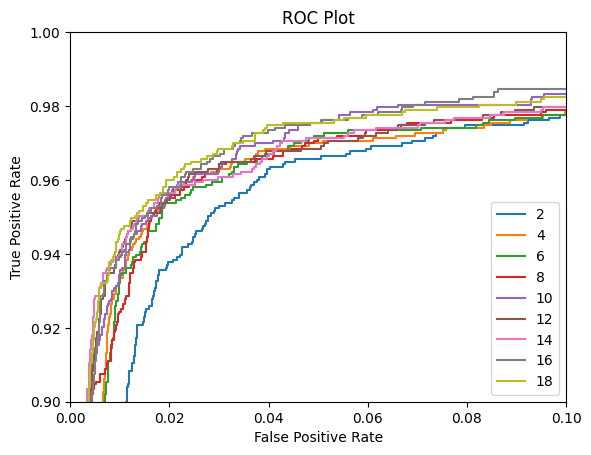

In [22]:
for n in np.arange(2,20)[::2]:
    
    clf = GMMBayes(n_components=n)
    clf.fit(X_train[:,0:4],y_train)
    
    y_prob = clf.predict_proba(X_test[:,0:4]) [:,1] 
        
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(n))

plt.legend()

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Plot')

plt.xlim(0,0.1)
plt.ylim(0.9,1);

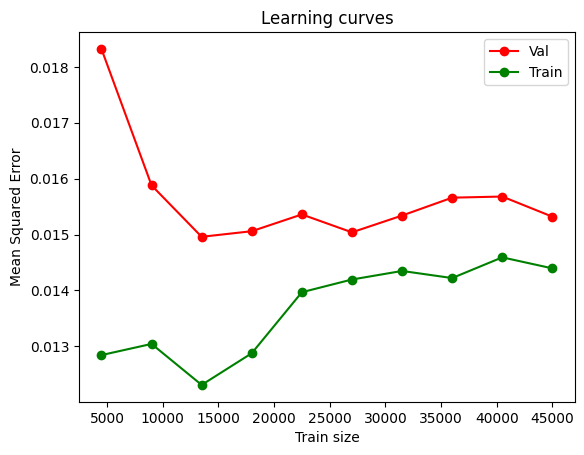

In [23]:
scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

train_sizes, train_scores_clf, test_scores_clf = \
    learning_curve(clf, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)


plt.plot(train_sizes, -test_scores_clf.mean(1), 'o-', color="r", label="Val")
plt.plot(train_sizes, -train_scores_clf.mean(1), 'o-', color="g", label="Train")
                   
plt.xlabel("Train size")
plt.ylabel("Mean Squared Error")
plt.title('Learning curves')
plt.legend(loc="best");

I would need more points

[[8511   61]
 [  97 1331]]


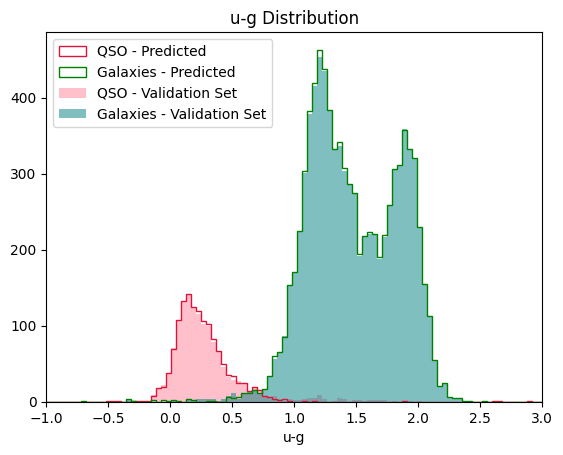

In [24]:
y_pred = clf.predict(X_test[:,0:4])

plt.hist(X_test[:,0][y_pred==1],color='crimson',histtype='step',bins=np.linspace(-1,3,100),label='QSO - Predicted')
plt.hist(X_test[:,0][y_pred==0],color='green',histtype='step',bins=np.linspace(-1,3,100),label='Galaxies - Predicted')
plt.xlim(-1,3)
plt.legend();

plt.hist(X_test[:,0][y_test==1],color='pink',bins=np.linspace(-1,3,100), label='QSO - Validation Set');
plt.hist(X_test[:,0][y_test==0],color='teal',alpha=0.5,bins=np.linspace(-1,3,100), label='Galaxies - Validation Set');
plt.title("u-g Distribution")
plt.xlabel('u-g')
plt.legend();

print(confusion_matrix(y_test, y_pred))

## KNeighborsClassifier

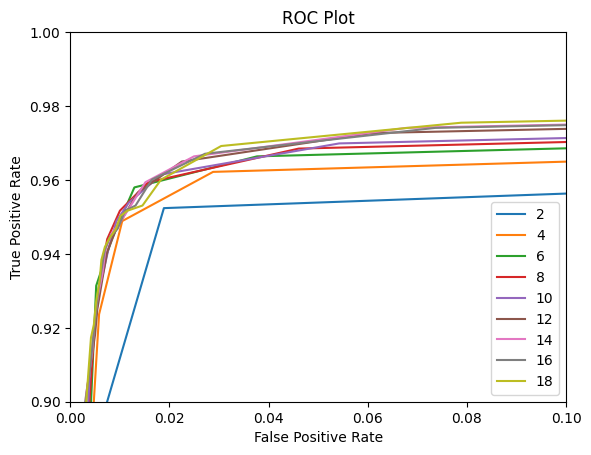

In [25]:
for n in np.arange(2,20)[::2]:
    
    clf = KNeighborsClassifier(n_neighbors=n)
    clf.fit(X_train[:,0:4],y_train)
    
    y_prob = clf.predict_proba(X_test[:,0:4]) [:,1] 
        
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(n))

plt.legend()

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Plot')

plt.xlim(0,0.1)
plt.ylim(0.9,1);

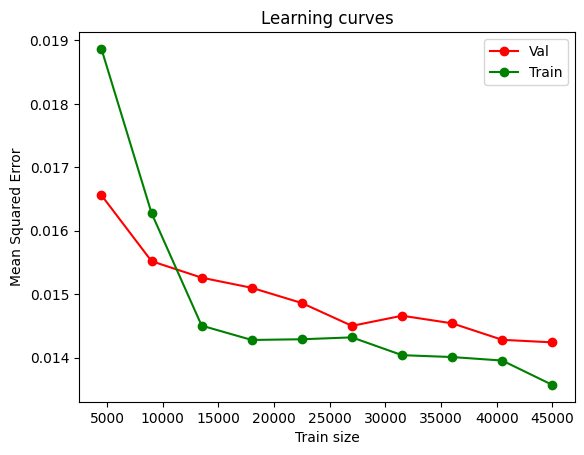

In [26]:
scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

train_sizes, train_scores_clf, test_scores_clf = \
    learning_curve(clf, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)


plt.plot(train_sizes, -test_scores_clf.mean(1), 'o-', color="r", label="Val")
plt.plot(train_sizes, -train_scores_clf.mean(1), 'o-', color="g", label="Train")
                   
plt.xlabel("Train size")
plt.ylabel("Mean Squared Error")
plt.title('Learning curves')
plt.legend(loc="best");

[[8518   54]
 [  88 1340]]


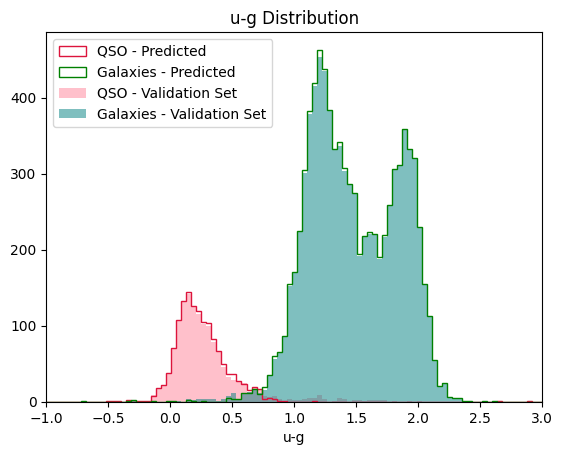

In [27]:
y_pred = clf.predict(X_test[:,0:4])

plt.hist(X_test[:,0][y_pred==1],color='crimson',histtype='step',bins=np.linspace(-1,3,100),label='QSO - Predicted')
plt.hist(X_test[:,0][y_pred==0],color='green',histtype='step',bins=np.linspace(-1,3,100),label='Galaxies - Predicted')
plt.xlim(-1,3)
plt.legend();

plt.hist(X_test[:,0][y_test==1],color='pink',bins=np.linspace(-1,3,100), label='QSO - Validation Set');
plt.hist(X_test[:,0][y_test==0],color='teal',alpha=0.5,bins=np.linspace(-1,3,100), label='Galaxies - Validation Set');
plt.title("u-g Distribution")
plt.xlabel('u-g')
plt.legend();

print(confusion_matrix(y_test, y_pred))